In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Exploratory Data Analysis

In [30]:
df=pd.read_csv("case1Data.csv")
print("Original Dataset:")
df.head()

Original Dataset:


,y,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,...,x_91,x_92,x_93,x_94,x_95,C_01,C_02,C_03,C_04,C_05
0,375.823073,6.359019,-13.367120,-2.483750,-6.641891,11.733539,NaN,-17.085361,22.194764,16.827888,...,-10.200888,3.980048,-4.433274,-1.473723,NaN,74.0,72.0,72.0,73.0,73.0
1,266.811730,3.873664,-8.470389,-3.055012,NaN,11.420983,1.822330,-13.694100,22.738654,20.307503,...,-9.740207,NaN,-2.629314,4.816987,-12.240248,74.0,72.0,72.0,73.0,73.0
2,267.271759,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,NaN,15.963889,...,-14.501970,10.054005,NaN,NaN,-11.107921,73.0,72.0,75.0,74.0,74.0
3,219.951294,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,...,-11.086963,2.019726,-8.531959,3.520833,NaN,71.0,72.0,73.0,71.0,72.0
4,289.697954,3.116458,-8.518713,-6.796050,NaN,7.646285,-3.118309,-13.102567,22.801217,16.680208,...,-9.117422,6.627601,-2.805531,5.914351,-11.240573,72.0,72.0,72.0,74.0,75.0


In [31]:
y_class=df["y"]
print(f"Number of samples in y: {len(y_class)} ")

data=df.drop("y",axis=1)
print(f"Number of samples in x: {len(data)} ")
print(f"Number of features: {len(data.columns)}")

cat_data = data[["C_01", "C_02", "C_03", "C_04", "C_05"]]
print(f"Number of categorical features: {len(cat_data.columns)}")

Number of samples in y: 100 
Number of samples in x: 100 
Number of features: 100
Number of categorical features: 5


In [51]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 100 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_01    87 non-null     float64
 1   x_02    79 non-null     float64
 2   x_03    85 non-null     float64
 3   x_04    86 non-null     float64
 4   x_05    88 non-null     float64
 5   x_06    88 non-null     float64
 6   x_07    84 non-null     float64
 7   x_08    80 non-null     float64
 8   x_09    87 non-null     float64
 9   x_10    87 non-null     float64
 10  x_11    88 non-null     float64
 11  x_12    76 non-null     float64
 12  x_13    81 non-null     float64
 13  x_14    88 non-null     float64
 14  x_15    87 non-null     float64
 15  x_16    87 non-null     float64
 16  x_17    86 non-null     float64
 17  x_18    90 non-null     float64
 18  x_19    88 non-null     float64
 19  x_20    79 non-null     float64
 20  x_21    82 non-null     float64
 21  x_22    88 non-null     float64
 22  x_23    84 no

In [70]:
data.describe()

,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,x_10,...,x_91,x_92,x_93,x_94,x_95,C_01,C_02,C_03,C_04,C_05
count,87.000000,79.000000,85.000000,86.000000,88.000000,88.000000,84.000000,80.000000,87.000000,87.000000,...,90.000000,81.000000,87.000000,90.000000,86.000000,78.000000,78.0,78.000000,78.000000,78.000000
mean,2.794472,-10.428729,-4.056112,-6.029949,9.815258,-4.057966,-13.534972,22.439790,14.002414,-4.879578,...,-12.617194,5.967559,-4.363874,3.350329,-10.545234,73.000000,72.0,72.794872,73.333333,72.846154
std,2.902720,2.553962,2.904539,3.132403,2.610209,3.295600,2.817909,2.797903,3.190918,2.948038,...,2.669706,2.686854,2.775601,2.927385,2.850058,1.376991,0.0,1.361426,1.401916,1.358732
min,-4.074607,-15.316637,-10.840247,-13.320232,2.099694,-10.965169,-19.564483,14.281130,5.574270,-11.858662,...,-19.259988,-1.428501,-12.460672,-2.406875,-16.268568,71.000000,72.0,71.000000,71.000000,71.000000
25%,0.508729,-12.469860,-5.994591,-8.586691,8.170811,-6.215558,-15.442493,20.467655,12.132821,-7.128910,...,-14.560693,4.192116,-6.257376,1.631049,-12.716112,72.000000,72.0,72.000000,72.000000,72.000000
50%,2.654725,-10.488042,-3.631874,-5.793856,9.984196,-3.771067,-13.568780,22.435510,13.670553,-4.798655,...,-12.453503,5.779682,-4.097142,3.183367,-10.462356,73.000000,72.0,73.000000,74.000000,73.000000
75%,4.911518,-8.496459,-2.121282,-3.870936,11.410208,-1.972570,-11.639240,24.276527,15.980201,-2.861620,...,-10.727816,7.501444,-2.792433,4.863970,-8.431565,74.000000,72.0,74.000000,74.000000,74.000000
max,8.737899,-4.419087,1.840223,0.839114,18.339822,4.062024,-5.976463,28.777232,21.531983,1.066570,...,-6.804967,12.575124,1.853439,9.991009,-4.520711,75.000000,72.0,75.000000,75.000000,75.000000


### 1.1 Categorical Variables

In [32]:
unique_values = {col: sorted(cat_data[col].astype(float).unique().tolist()) for col in cat_data.columns}
print(unique_values)

{'C_01': [71.0, 72.0, 73.0, 74.0, nan, 75.0], 'C_02': [72.0, nan], 'C_03': [71.0, 72.0, 73.0, 74.0, 75.0, nan], 'C_04': [71.0, 72.0, 73.0, 74.0, 75.0, nan], 'C_05': [71.0, 72.0, 73.0, 74.0, 75.0, nan]}


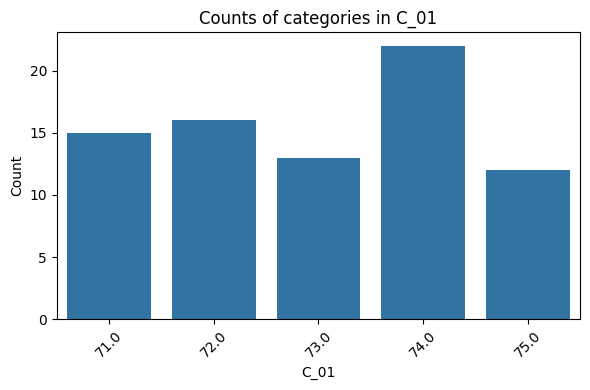

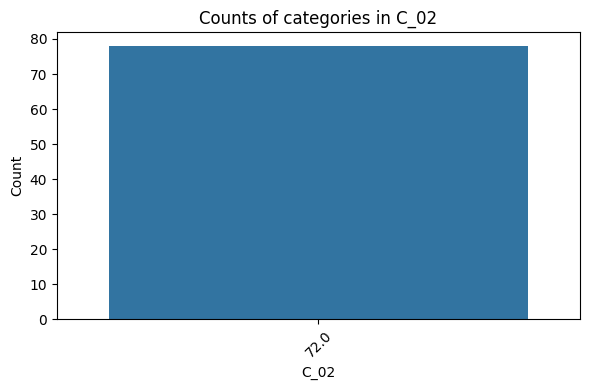

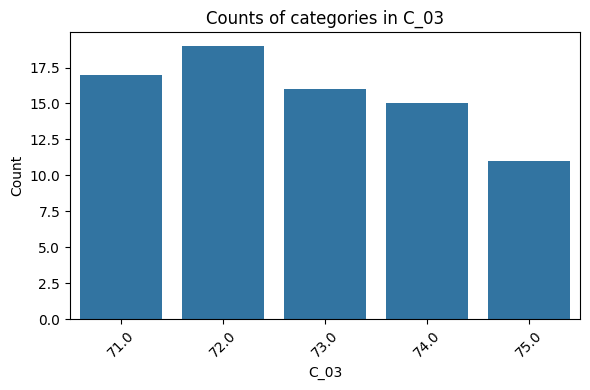

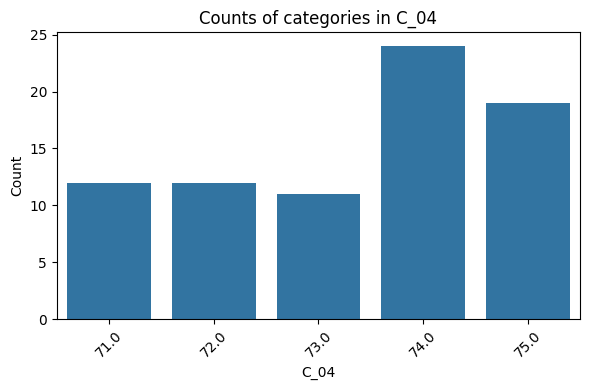

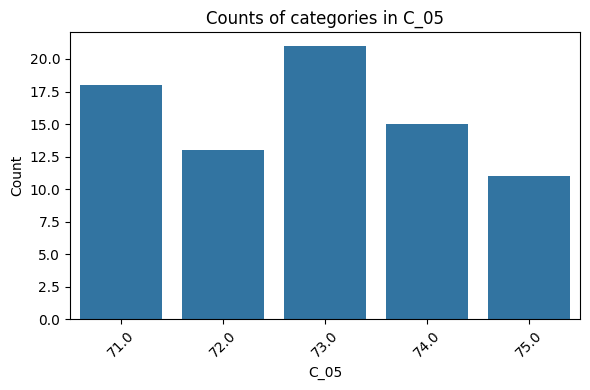

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop over each categorical feature
for col in cat_data.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=cat_data, x=col, order=sorted(cat_data[col].dropna().unique()))
    plt.title(f"Counts of categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)  # rotate x labels if too long
    plt.tight_layout()
    plt.show()

C:\Users\Maria\AppData\Local\Temp\ipykernel_11652\3535667182.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Maria\AppData\Local\Temp\ipykernel_11652\3535667182.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Maria\AppData\Local\Temp\ipykernel_11652\3535667182.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Maria\AppData\Local\Temp\ipykernel_11652\3535667182.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotat

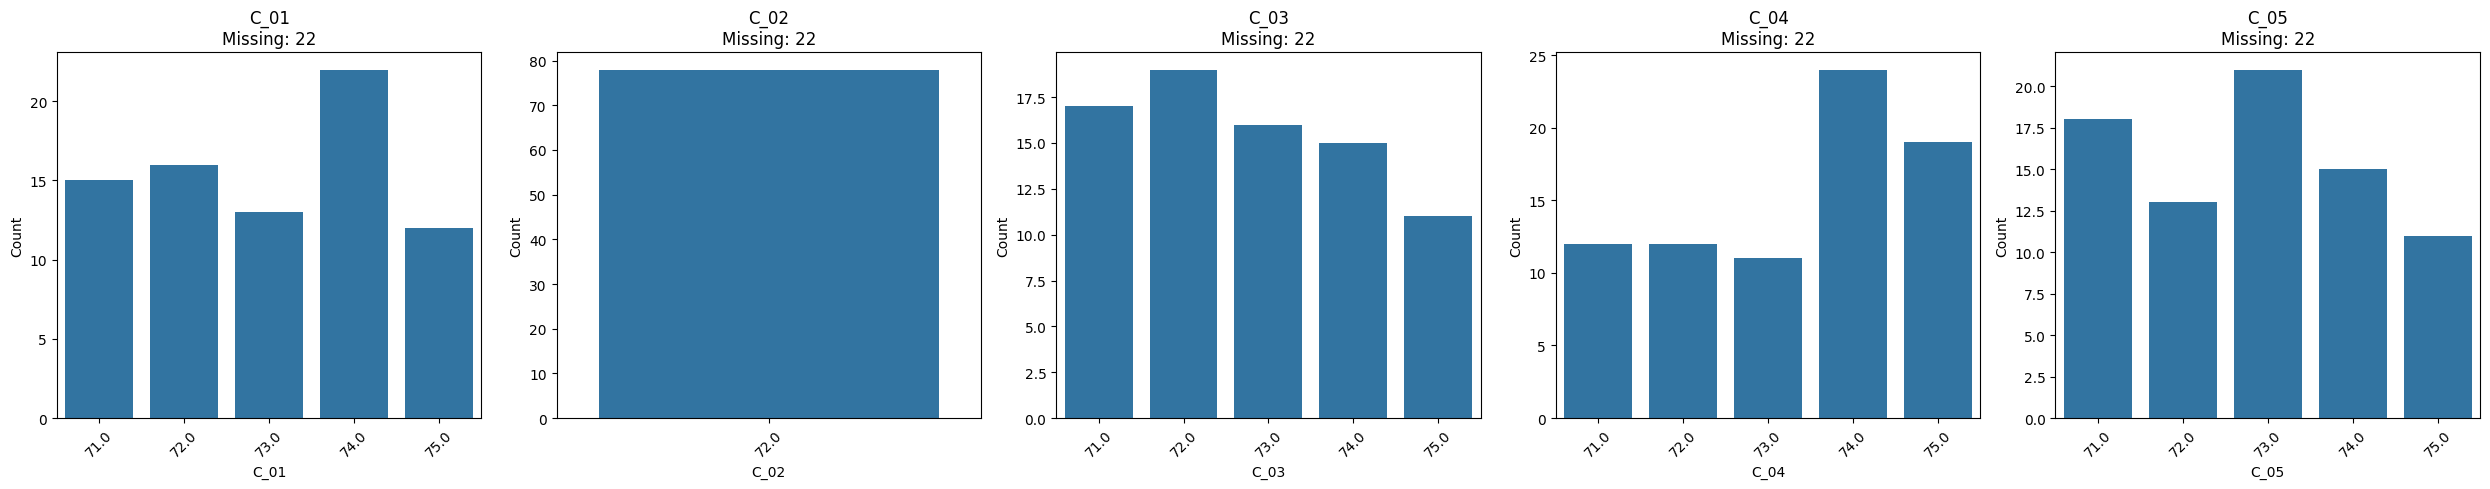

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Number of categorical features
n_features = len(cat_data.columns)

# Create subplots
fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 5))

# If only one feature, axes is not iterable
if n_features == 1:
    axes = [axes]

# Loop over each categorical feature
for i, col in enumerate(cat_data.columns):
    ax = axes[i]
    
    # Count plot
    sns.countplot(
        data=cat_data, 
        x=col, 
        order=sorted(cat_data[col].dropna().unique()), 
        ax=ax
    )
    
    # Rotate x labels for readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    
    # Set title with number of missing values
    n_missing = cat_data[col].isna().sum()
    ax.set_title(f"{col}\nMissing: {n_missing}")
    
    # Labels
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [75]:
# Check which rows have all categorical values missing
all_missing_rows = cat_data.isna().all(axis=1)

# Print number of such rows
print("Number of rows with all categorical values missing:", all_missing_rows.sum())

# Optional: see the row indices
print("Row indices with all categorical values missing:", all_missing_rows[all_missing_rows].index.tolist())

Number of rows with all categorical values missing: 22
Row indices with all categorical values missing: [8, 10, 14, 16, 21, 24, 28, 30, 34, 40, 57, 58, 59, 62, 64, 66, 72, 84, 85, 88, 91, 99]


- C_01, C_03, C_04, C_05 all have values from 71 to 75 (5 possible values)
- C_02 only has 72; we can drop this variable
- WARNING: C2 might be important in the test data

### 1.2 Missing values

Missing values per column

Maximum missing values in a column: 27
Feature(s) with maximum missing values: ['x_85']


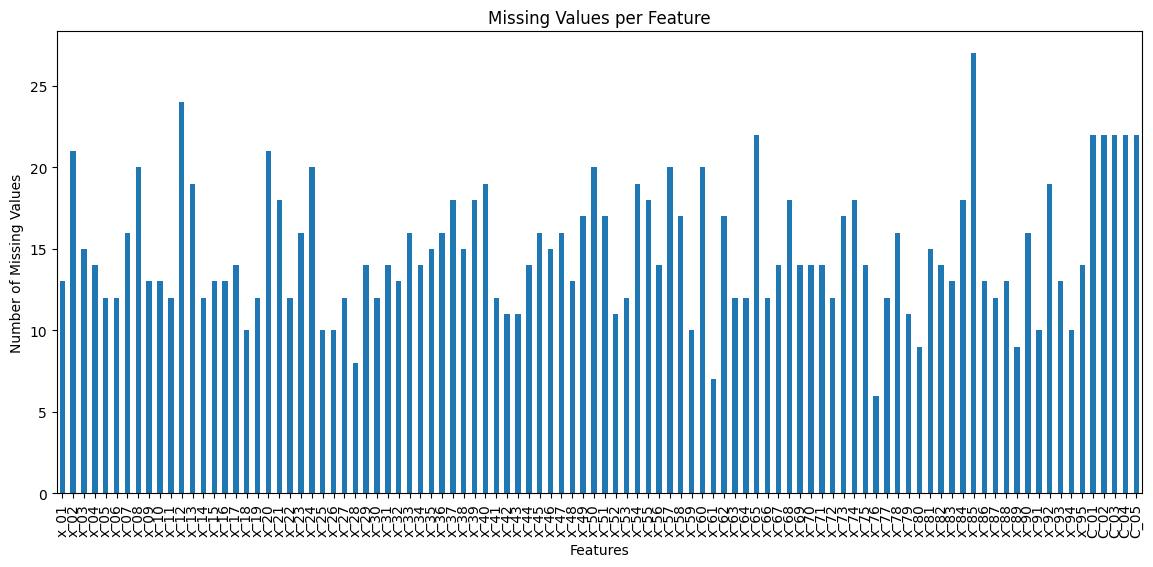

In [34]:
missing_per_column = data.isnull().sum()

# Maximum missing values in any feature
max_missing_col = missing_per_column.max()
print("Maximum missing values in a column:", max_missing_col)

# Which feature(s) have this maximum
features_with_max_missing = missing_per_column[missing_per_column == max_missing_col].index.tolist()
print("Feature(s) with maximum missing values:", features_with_max_missing)

plt.figure(figsize=(14,6))
missing_per_column.plot(kind='bar')
plt.title("Missing Values per Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.show()

Missing values per row

Maximum missing values in a row: 32
Row index(es) with maximum missing values: [57]
Number of rows with at least one missing value: 100


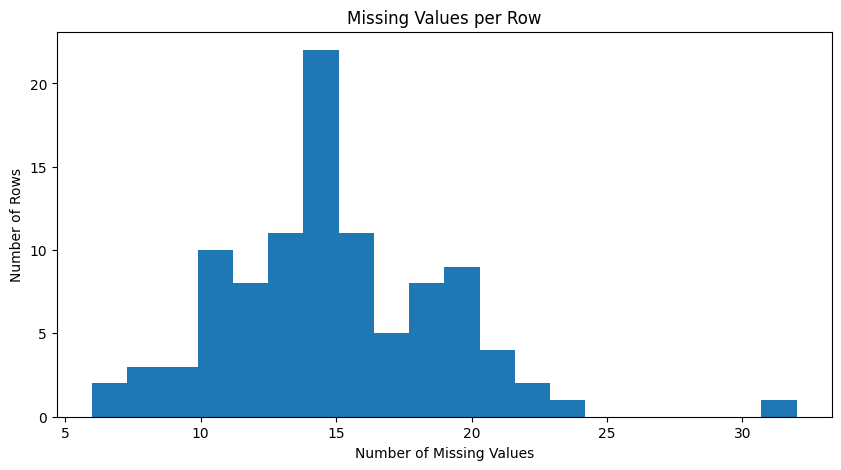

In [36]:
missing_per_row = data.isnull().sum(axis=1)

# Maximum missing values in any row
max_missing_row = missing_per_row.max()
print("Maximum missing values in a row:", max_missing_row)

# Which row(s) have this maximum
rows_with_max_missing = missing_per_row[missing_per_row == max_missing_row].index.tolist()
print("Row index(es) with maximum missing values:", rows_with_max_missing)

rows_with_missing = (missing_per_row > 0).sum()
print("Number of rows with at least one missing value:", rows_with_missing)

plt.figure(figsize=(10,5))
plt.hist(missing_per_row, bins=20)
plt.title("Missing Values per Row")
plt.xlabel("Number of Missing Values")
plt.ylabel("Number of Rows")
plt.show()

- Impute the median of the feature for missing values since we have few obs

### 1.3 Correlation

Linear correlation

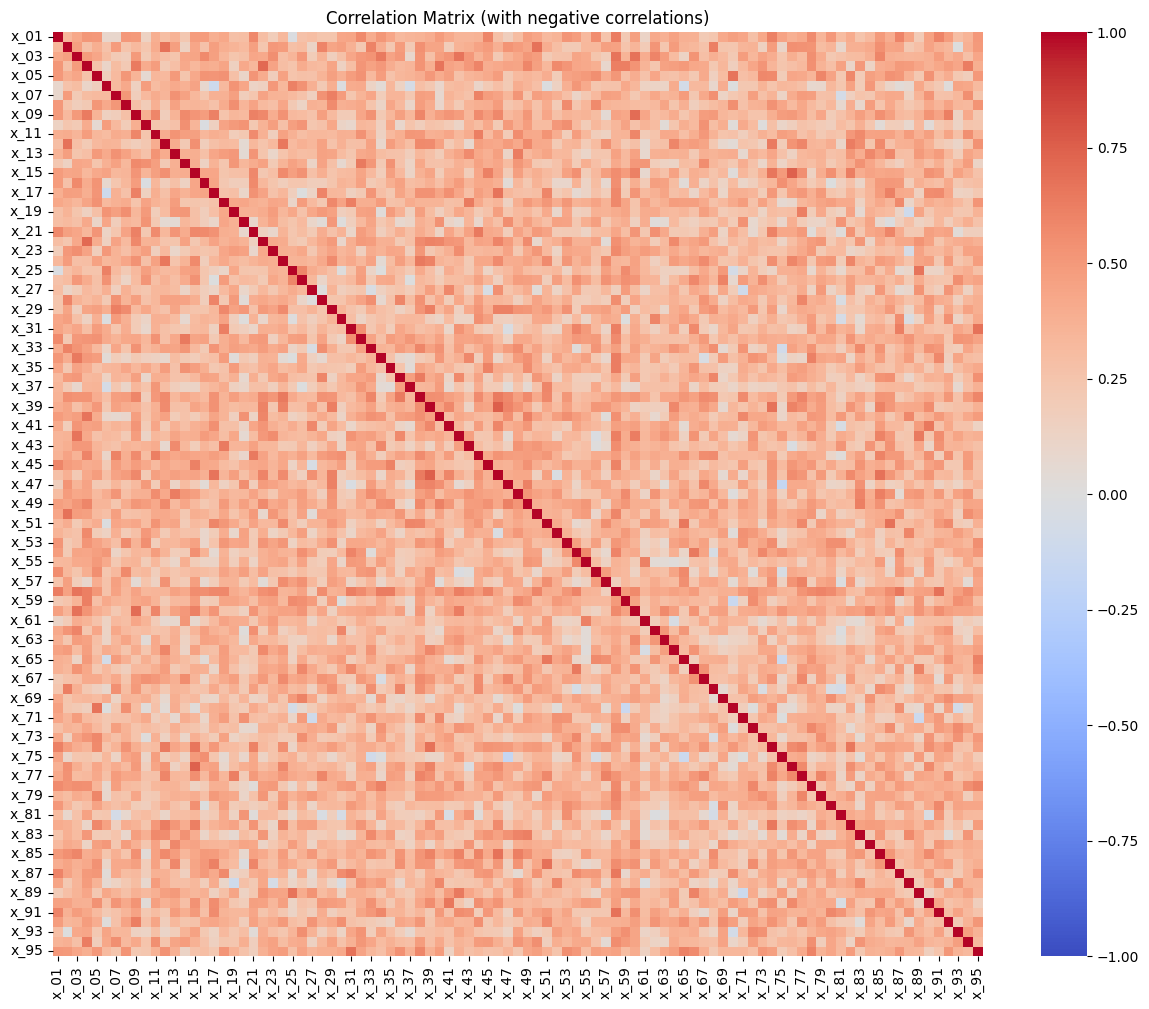

In [49]:
data_cont=data.drop(columns=cat_data.columns)
corr = data_cont.corr()
plt.figure(figsize=(15,12))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, annot=False)
plt.title("Correlation Matrix (with negative correlations)")
plt.show()

Linear correlation above 0.7

In [50]:
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
high_corr = corr_pairs[corr_pairs > 0.7].sort_values(ascending=False)
print(high_corr)

x_46  x_39    0.751971
x_39  x_46    0.751971
x_76  x_15    0.747985
x_15  x_76    0.747985
x_04  x_22    0.716159
x_22  x_04    0.716159
dtype: float64


Spearman correlation

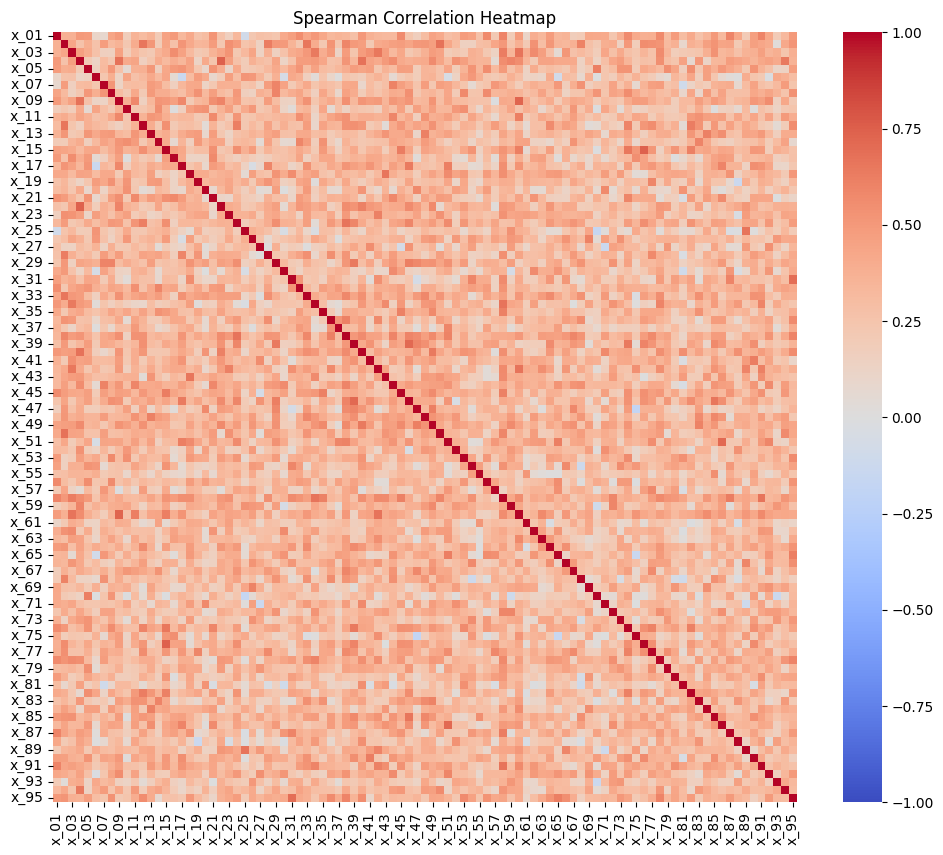

In [68]:
# Spearman correlation
spearman_corr = data_cont.corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap")
plt.show()

In [69]:
spear_pairs = spearman_corr.unstack()
spear_pairs = spear_pairs[spear_pairs.index.get_level_values(0) != spear_pairs.index.get_level_values(1)]
high_corr = spear_pairs[spear_pairs > 0.7].sort_values(ascending=False)
print(high_corr)

x_04  x_22    0.746083
x_22  x_04    0.746083
x_76  x_15    0.744234
x_15  x_76    0.744234
x_09  x_60    0.731047
x_60  x_09    0.731047
x_51  x_86    0.717438
x_86  x_51    0.717438
x_46  x_39    0.712886
x_39  x_46    0.712886
dtype: float64


### 1.4 Feature Variance

- Variances between 5 and 10 → all features have moderate spread.
- Outliers in these features are not a big concern since the variance is moderate

In [66]:
numeric_cols = data_cont.select_dtypes(include='number').columns
feature_variance = data_cont[numeric_cols].var()
feature_variance.max(), feature_variance.min()

(np.float64(10.860976917924484), np.float64(5.976478283172355))

## 2. Data Preprocessing